# Chapitre 8 — Visualisation exploratoire

**Durée estimée : 8-10 heures**

---

## Objectifs d'apprentissage

À la fin de ce chapitre, vous serez capable de :

1. **Choisir** le type de graphique approprié selon la question et les données
2. **Créer** des visualisations avec Matplotlib et Seaborn
3. **Personnaliser** les graphiques pour une communication efficace
4. **Appliquer** les bonnes pratiques de visualisation (lisibilité, accessibilité)

---

## 8.1 Principes de visualisation

### Choisir le bon graphique

```
┌──────────────────────────────────────────────────────────────────────┐
│                    QUEL GRAPHIQUE CHOISIR ?                          │
├──────────────────────────────────────────────────────────────────────┤
│                                                                      │
│  COMPARAISON                    DISTRIBUTION                         │
│  ┌─────────────────┐           ┌─────────────────┐                  │
│  │ Bar chart       │           │ Histogram       │                  │
│  │ (catégories)    │           │ (1 variable)    │                  │
│  │                 │           │                 │                  │
│  │ Grouped bar     │           │ Boxplot         │                  │
│  │ (comparaison)   │           │ (outliers)      │                  │
│  └─────────────────┘           └─────────────────┘                  │
│                                                                      │
│  RELATION                       ÉVOLUTION                            │
│  ┌─────────────────┐           ┌─────────────────┐                  │
│  │ Scatter plot    │           │ Line chart      │                  │
│  │ (2 numériques)  │           │ (temps)         │                  │
│  │                 │           │                 │                  │
│  │ Heatmap         │           │ Area chart      │                  │
│  │ (corrélations)  │           │ (volumes)       │                  │
│  └─────────────────┘           └─────────────────┘                  │
│                                                                      │
│  COMPOSITION                    PARTIE D'UN TOUT                     │
│  ┌─────────────────┐           ┌─────────────────┐                  │
│  │ Stacked bar     │           │ Pie chart       │                  │
│  │ (composition    │           │ (< 5 catégories)│                  │
│  │ dans le temps)  │           │                 │                  │
│  └─────────────────┘           └─────────────────┘                  │
└──────────────────────────────────────────────────────────────────────┘
```

---

### Guide de sélection rapide

| Question | Graphique recommandé |
|----------|---------------------|
| Comment se distribue une variable ? | Histogramme, KDE |
| Y a-t-il des outliers ? | Boxplot |
| Quelle est la tendance dans le temps ? | Line chart |
| Comment comparer des catégories ? | Bar chart |
| Y a-t-il une relation entre deux variables ? | Scatter plot |
| Quelles variables sont corrélées ? | Heatmap |
| Quelle est la composition d'un tout ? | Pie chart (< 5 parts) ou bar chart |

---

### ✍️ Exercice 8.1 : Choix du graphique (10 min)

Pour chaque question, identifiez le type de graphique le plus approprié :

| Question | Graphique |
|----------|-----------|
| Comment les ventes ont-elles évolué sur 12 mois ? | _____ |
| Quelle est la répartition des âges de nos clients ? | _____ |
| Y a-t-il un lien entre le prix et les ventes ? | _____ |
| Comment se comparent les ventes par région ? | _____ |
| Quelle part de marché a chaque concurrent ? | _____ |
| Y a-t-il des valeurs extrêmes dans les salaires ? | _____ |

---

### 🤖 IA : Générer du code Matplotlib

**Prompt efficace :**

```
Génère du code Matplotlib pour créer :
- Un graphique à barres horizontales
- Données : {'Python': 85, 'SQL': 72, 'R': 45, 'Excel': 90}
- Triées par valeur décroissante
- Couleurs dégradées du vert (max) au rouge (min)
- Titre : "Compétences de l'équipe Data"
- Labels sur les barres
- Figure de 10x6 pouces
```

---

### ✍️ Exercice 8.1.2 : Créer un dashboard Matplotlib (20 min)

Créer un dashboard 2x2 avec Matplotlib contenant 4 graphiques différents :

- Line chart : Évolution mensuelle des ventes sur 12 mois, avec une ligne horizontale pour la moyenne
- Bar chart : Comparaison des ventes par région (Nord, Sud, Est, Ouest)
- Histogramme : Distribution des âges des clients
- Pie chart : Répartition des ventes par région en pourcentage

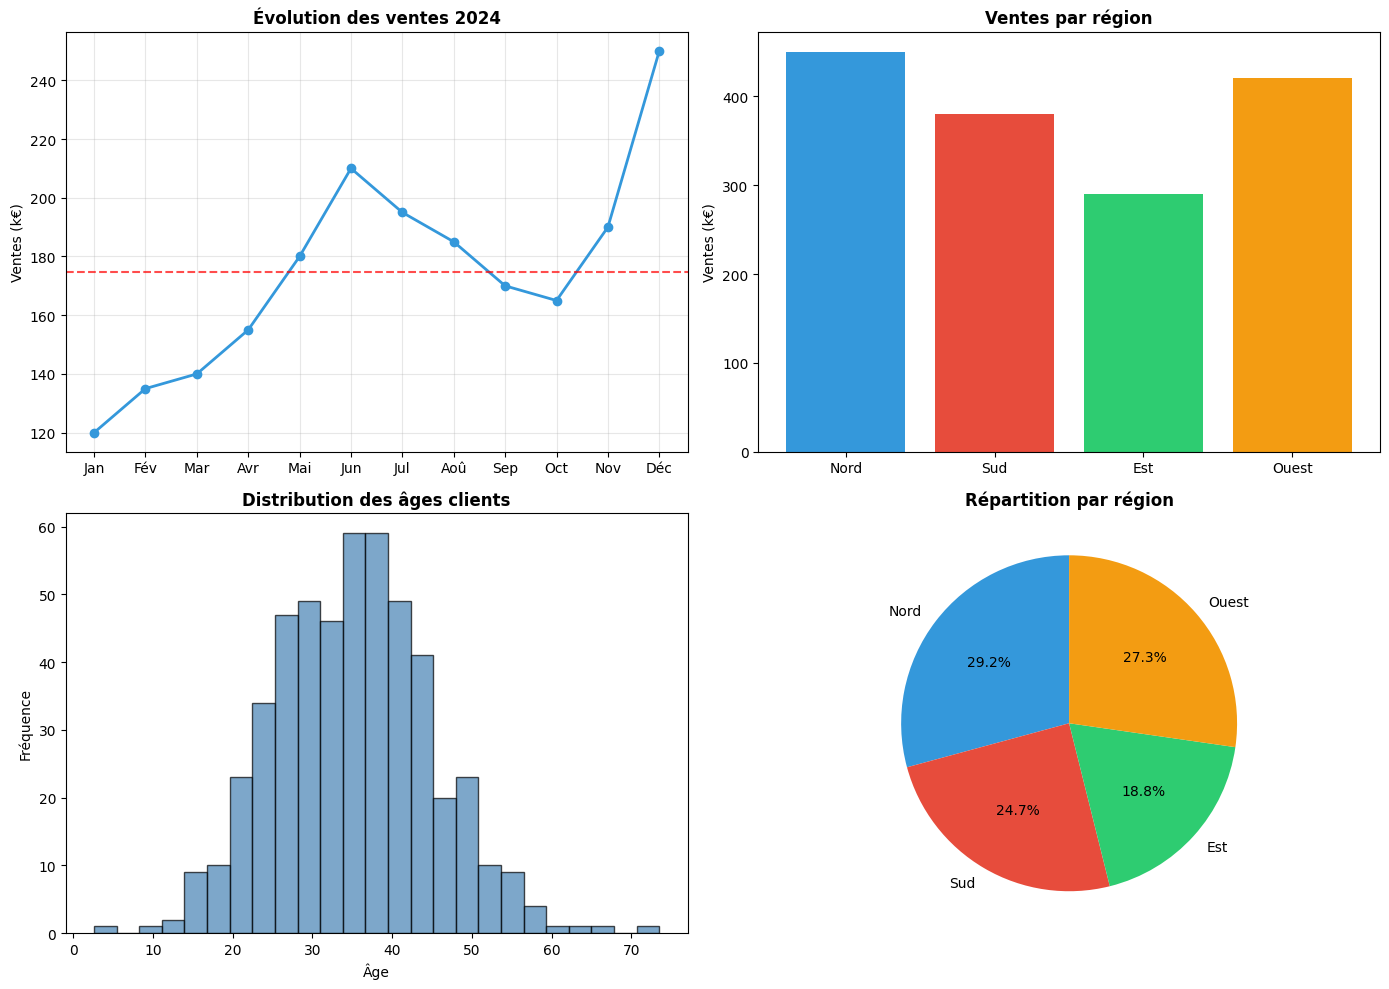

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Données
np.random.seed(42)

df_ventes = pd.DataFrame({
    'mois': ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Jun', 'Jul', 'Aoû', 'Sep', 'Oct', 'Nov', 'Déc'],
    'ventes': [120, 135, 140, 155, 180, 210, 195, 185, 170, 165, 190, 250]
})

df_regions = pd.DataFrame({
    'region': ['Nord', 'Sud', 'Est', 'Ouest'],
    'ventes': [450, 380, 290, 420]
})

df_clients = pd.DataFrame({
    'age': np.random.normal(35, 10, 500)
})


# Créer un dashboard 2x2
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Line chart : évolution mensuelle
axes[0, 0].plot(df_ventes['mois'], df_ventes['ventes'], marker='o', color='#3498db', linewidth=2)
axes[0, 0].set_title('Évolution des ventes 2024', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Ventes (k€)')
axes[0, 0].grid(True, alpha=0.3)
# Ajoutez une ligne horizontale pour la moyenne
axes[0, 0].axhline(y=np.mean(df_ventes['ventes']), color='red', linestyle='--', alpha=0.7)

# 2. Bar chart : ventes par région
axes[0, 1].bar(df_regions['region'], df_regions['ventes'], color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'])
axes[0, 1].set_title('Ventes par région', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Ventes (k€)')

# 3. Histogram : distribution des âges
axes[1, 0].hist(df_clients['age'], bins=25, color='steelblue', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Distribution des âges clients', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Âge')
axes[1, 0].set_ylabel('Fréquence')

# 4. Pie chart : répartition par région (en %)
axes[1, 1].pie(df_regions['ventes'], labels=df_regions['region'], autopct='%1.1f%%', startangle=90,
               colors=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'])
axes[1, 1].set_title('Répartition par région', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('dashboard.png', dpi=150)  # Sauvegarder
plt.show()